# House Price Prediction using PCA & Linear Regression
**Course:** MAI391 - Mathematics for Machine Learning

Mục tiêu của notebook này là xây dựng mô hình dự đoán từ con số 0, ứng dụng **Phân tích thành phần chính (PCA)**, **Đại số tuyến tính** và **Giải tích** bằng thư viện `numpy`.

### 1. Problem Formulation & PCA
Dữ liệu gốc có rất nhiều đặc trưng gây nhiễu. Thay vì chọn ngẫu nhiên, ta dùng PCA để nén 5 đặc trưng quan trọng về diện tích/chất lượng xuống còn 2 biến tổng hợp (Principal Components).

Mô hình dự đoán cuối cùng có dạng ma trận:
$$\hat{\mathbf{y}} = \mathbf{X}\mathbf{w}$$

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Tùy chỉnh hiển thị ma trận của numpy để dễ nhìn
np.set_printoptions(precision=4, suppress=True)

### 2. PCA & Data Preprocessing
**Bước 1:** Nén dữ liệu bằng PCA thông qua Ma trận hiệp phương sai và Phân tích Trị riêng (Eigendecomposition).
$$S = \frac{1}{N} \mathbf{X}_{centered}^T \mathbf{X}_{centered}$$
$$S \mathbf{v} = \lambda \mathbf{v}$$

**Bước 2:** Chuẩn hóa Min-Max cho các Thành phần chính để đảm bảo thuật toán tối ưu hội tụ ổn định.
$$z = \frac{x - \min(x)}{\max(x) - \min(x)}$$

In [21]:
# 1. Đọc dữ liệu từ file CSV
df = pd.read_csv('../data/train.csv')

# 2. Thuật toán PCA từ scratch
features_pca = ['GrLivArea', 'TotalBsmtSF', 'GarageArea', '1stFlrSF', 'OverallQual']
X_multi = df[features_pca].fillna(0).values 
y_raw = df['SalePrice'].values.reshape(-1, 1)

# Chuẩn hóa Z-score trước khi PCA
mu = np.mean(X_multi, axis=0)
std = np.std(X_multi, axis=0)
X_centered = (X_multi - mu) / std

# Tính Ma trận hiệp phương sai & Trị riêng/Vector riêng
N_samples = X_centered.shape[0]
Cov_Matrix = (1 / N_samples) * (X_centered.T @ X_centered)
eigenvalues, eigenvectors = np.linalg.eigh(Cov_Matrix)

# Sắp xếp và lấy 2 Vector riêng tốt nhất
sorted_idx = np.argsort(eigenvalues)[::-1]
W_pca = eigenvectors[:, sorted_idx][:, :2]

# Chiếu dữ liệu xuống không gian 2 chiều
X_pca = X_centered @ W_pca

# 3. Hàm chuẩn hóa Min-Max
def min_max_scaler(data):
    min_val = np.min(data, axis=0)
    max_val = np.max(data, axis=0)
    scaled_data = (data - min_val) / (max_val - min_val)
    return scaled_data, min_val, max_val

X_scaled, X_min, X_max = min_max_scaler(X_pca)
y_scaled, y_min, y_max = min_max_scaler(y_raw)

print("Kích thước dữ liệu gốc:", X_multi.shape)
print("Kích thước ma trận X sau PCA (2 biến):", X_scaled.shape)

Kích thước dữ liệu gốc: (1460, 5)
Kích thước ma trận X sau PCA (2 biến): (1460, 2)


### 3. The Design Matrix (Thiết lập Ma trận)
Thêm một cột toàn số `1` vào đầu ma trận $\mathbf{X}$ để đại diện cho hệ số tự do (bias) $w_0$. Ma trận thiết kế $\mathbf{X}$ lúc này có kích thước $N \times 3$.

In [30]:
N = X_scaled.shape[0]
ones_column = np.ones((N, 1))
X = np.hstack((ones_column, X_scaled))

y = y_scaled # Đổi tên cho gọn

print("Ma trận thiết kế X (5 dòng đầu):\n", X[:5])

Ma trận thiết kế X (5 dòng đầu):
 [[1.     0.7409 0.2225]
 [1.     0.7374 0.4356]
 [1.     0.726  0.2237]
 [1.     0.7312 0.2046]
 [1.     0.652  0.1753]]


### 4. Objective Function & Normal Equation
Hàm mất mát Mean Squared Error (MSE):
$$L(\mathbf{w}) = \frac{1}{2N} \|\mathbf{X}\mathbf{w} - \mathbf{y}\|_2^2$$

Cho đạo hàm $\nabla L(\mathbf{w}) = 0$, ta tìm được nghiệm giải tích (Normal Equation) tuyệt đối:
$$\mathbf{w} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

In [29]:
# Tính toán Normal Equation
X_T = X.T
w_normal = np.linalg.inv(X_T @ X) @ X_T @ y

print("Trọng số w tối ưu (Normal Equation):")
print(w_normal)

Trọng số w tối ưu (Normal Equation):
[[ 1.1241]
 [-1.1277]
 [-0.2351]]


### 5. Gradient Descent (Tối ưu bằng Vòng lặp)
Cập nhật trọng số liên tục ngược hướng đạo hàm:
$$\mathbf{w}_{t+1} = \mathbf{w}_t - \alpha \nabla L(\mathbf{w}_t)$$
Với $\alpha$ là Learning Rate, và $\nabla L(\mathbf{w}_t) = \frac{1}{N} \mathbf{X}^T (\mathbf{X}\mathbf{w}_t - \mathbf{y})$.

Trọng số w tối ưu (Gradient Descent):
[[ 1.1241]
 [-1.1277]
 [-0.2351]]


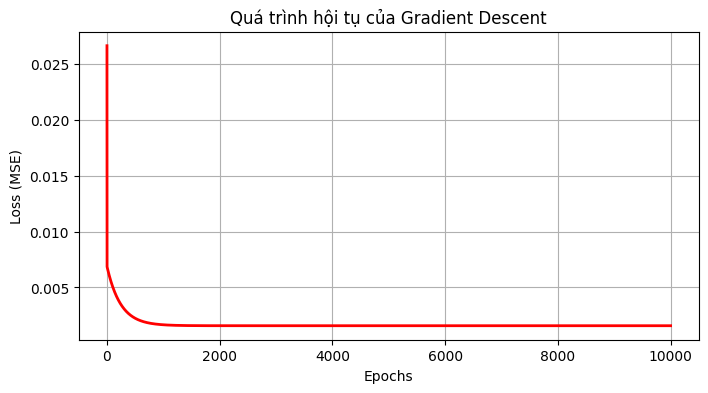

In [ ]:
# Cài đặt Gradient Descent
learning_rate = 0.5
epochs = 2000 # có thể Tăng lên thành 10000 để hội tụ hoàn toàn 

w_gd = np.zeros((X.shape[1], 1))
loss_history = []

for i in range(epochs):
    y_pred = X @ w_gd
    gradient = (1/N) * X_T @ (y_pred - y)
    w_gd = w_gd - learning_rate * gradient
    
    loss = (1/(2*N)) * np.sum((y_pred - y)**2)
    loss_history.append(loss)

print("Trọng số w tối ưu (Gradient Descent):")
print(w_gd)

# Vẽ biểu đồ
plt.figure(figsize=(8, 4))
plt.plot(range(epochs), loss_history, color='red', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss (MSE)')
plt.title('Quá trình hội tụ của Gradient Descent')
plt.grid(True)
plt.show()

### 6. Evaluation (Đánh giá Mô hình)
Đảo ngược quá trình chuẩn hóa (Inverse Scaling) để tính Root Mean Squared Error (RMSE) theo đơn vị Đô-la thực tế.

In [28]:
# Dự đoán với trọng số tối ưu
y_pred_scaled = X @ w_gd

# Inverse Transform về giá trị tiền thực tế
y_pred_real = y_pred_scaled * (y_max - y_min) + y_min
y_real = y_scaled * (y_max - y_min) + y_min

# Tính sai số RMSE
rmse = np.sqrt(np.mean((y_pred_real - y_real)**2))
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")

Root Mean Squared Error (RMSE): $40,340.70
